In [12]:
# Importing libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [13]:
# Define the models
MODEL_NAME = 'gpt-4o-mini'
generator_model = ChatOpenAI(model=MODEL_NAME)
evaluator_model = ChatOpenAI(model=MODEL_NAME)
optimizer_model = ChatOpenAI(model=MODEL_NAME)

In [14]:
# Structured output
class TweetEvaluation(BaseModel):
    evaluation: Literal['approved', 'need_improvement'] = Field(..., description="Final evaluation result")
    feedback: str = Field(..., description="feedback for the tweet")

# structured model
structured_evaluator_model = evaluator_model.with_structured_output(TweetEvaluation)

In [15]:
# Define the state
class TweetState(TypedDict):
    topic:str 
    tweet: str 
    evaluation: Literal['approved', 'need_improvement']
    feedback: str 
    iteration:int 
    max_iteration:int 

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [16]:
def generate_tweet(state: TweetState):
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
                     Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
                     Rules:
                     - Do NOT use question-answer format.
                     - Max 280 characters.
                     - Use observational humor, irony, sarcasm, or cultural references.
                     - Think in meme logic, punchlines, or relatable takes.
                     - Use simple, day to day english""")
    ]

    # send generator llm
    response = generator_model.invoke(messages).content

    # return response
    return {"tweet": response, "tweet_history": [response]}

In [17]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""Evaluate the following tweet: 
                 Tweet: "{state['tweet']}"
                 Use the criteria below to evaluate the tweet:
                 
                1. Originality – Is this fresh, or have you seen it a hundred times before?  
                2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
                3. Punchiness – Is it short, sharp, and scroll-stopping?  
                4. Virality Potential – Would people retweet or share it?  
                5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?
                
                Auto-reject if:
                - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
                - It exceeds 280 characters
                - It reads like a traditional setup-punchline joke
                - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)
                
                ### Respond ONLY in structured format:
                # - evaluation: "approved" or "needs_improvement"  
                # - feedback: One paragraph explaining the strengths and weaknesses """)
                ]

    response = structured_evaluator_model.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [18]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
                     Improve the tweet based on this feedback:
                     "{state['feedback']}"
                     
                     Topic: "{state['topic']}"
                     Original Tweet:
                     {state['tweet']}

                     Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.""")]

    response = optimizer_model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [19]:
# conditional node
def route_evaluation(state: TweetState):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

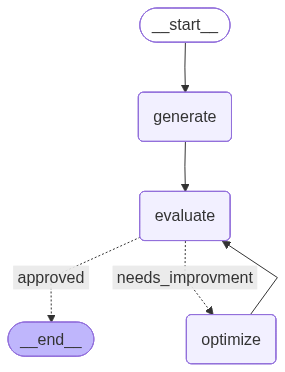

In [20]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvment': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow

In [23]:
initial_state = {
    "topic": "Indian railway",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [28]:
from IPython.display import display, Markdown

display(Markdown(result['tweet']))

Indian Railways: where the only thing moving faster than your train is the chaiwallah sprinting to catch you before that 5-minute stop turns into an hour. Forget "time is money"; here, it’s all about "time is tea!" 🫖🚂 #TrainLife #ChaiFirst